# Reconstructing Atmospheric Dynamics from Real Weather Data

Earlier we learned how deterministic equations can produce chaotic and unpredictable behaviour. Now let's try to apply that to real observations from the Danish Meteorological Institute (DMI).

By using [Takens' Theorem](https://www.youtube.com/watch?v=6i57udsPKms), we can reconstruct the phase space of the atmosphere from a single temperature time series measured in Copenhagen during the summer of 2024. By plotting the temperature against time-delayed versions of itself, the hidden dynamical structure should reveal itself directly from the data without any use of equations.

The goal is to investigate whether real weather observations carry signatures of deterministic chaos similar to those found in the Lorenz attractor.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

## Extract the data

In [2]:
# extract data from DMI API
url = "https://opendataapi.dmi.dk/v2/metObs/collections/observation/items"

params = {
    "stationId": "06180",
    "parameterId": "temp_dry",
    "datetime": "2024-06-01T00:00:00Z/2024-08-31T23:59:59Z",
    "limit": 20000
}

response = requests.get(url, params=params)
data = response.json()

print("Number of observations: " + str(len(data["features"])))

Number of observations: 13247


In [3]:
# Extract the data into a DataFrame
records = [feature["properties"] for feature in data["features"]]

df = pd.DataFrame(records)
df["observed"] = pd.to_datetime(df["observed"])
df = df.sort_values("observed").reset_index(drop=True)
df = df[["observed", "value"]].rename(columns={"value": "temp_c"})
df = df.set_index("observed")

print(df.shape)
df.head() # Display the first few rows of the DataFrame

(13247, 1)


,temp_c
observed,
2024-06-01 00:00:00+00:00,15.8
2024-06-01 00:10:00+00:00,15.6
2024-06-01 00:20:00+00:00,15.5
2024-06-01 00:30:00+00:00,15.9
2024-06-01 00:40:00+00:00,16.2


In [4]:
# resample hourly averages
hourly = df.resample("H").mean()
hourly.columns = ["temp_c"]
hourly = hourly.dropna()

print(hourly.shape)
hourly.head() # Display the first few rows of the hourly resampled DataFrame

(2208, 1)


,temp_c
observed,
2024-06-01 00:00:00+00:00,15.866667
2024-06-01 01:00:00+00:00,16.166667
2024-06-01 02:00:00+00:00,16.183333
2024-06-01 03:00:00+00:00,16.416667
2024-06-01 04:00:00+00:00,16.883333


## Time Series Plot

Before reconstructing the phase space, let's take a look at the raw data to get a fe. This gives us a feel for the signal we're working with — how it behaves, what patterns are visible, and whether it looks purely random or has some underlying structure.

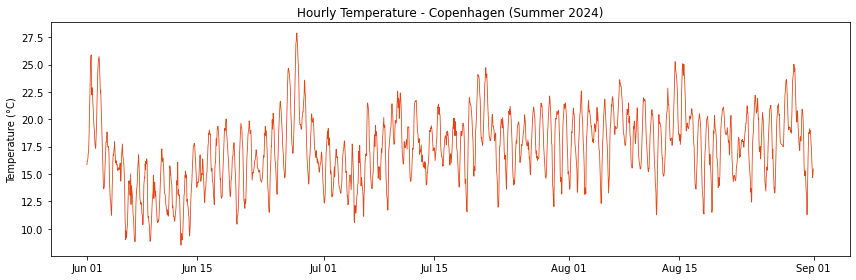

In [14]:
# quick plot of summer temperature series
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(hourly.index.tz_localize(None), hourly["temp_c"], 
        color="#e64413", lw=0.8)

ax.set_title("Hourly Temperature - Copenhagen (Summer 2024)")
ax.set_ylabel("Temperature (°C)")
ax.set_xlabel("")

import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.tight_layout()
plt.show()

Comments:

- We can clearly distinguish the daily cycles — a regular oscillation caused by daytime heating and nighttime cooling.

- A global maximum around late June, reaching nearly $28^\circ\text{C}$.

- A global minimum around June 15th, with temperatures dropping to around $9{-}10^\circ\text{C}$.

- Generally warmer and more stable conditions during July and August.

The signal is neither purely periodic nor completely random. While the 24-hour cycle dominates the data, the amplitude and timing of the fluctuations vary continuously over time. This suggests that the atmosphere is influenced by both regular forcing (24h day cycle) and complex nonlinear dynamics — driven by pressure systems, turbulence, and the chaotic nature of atmospheric flow.

## Autocorrelation plot:
How similar is the temperature to itself at different time delays?

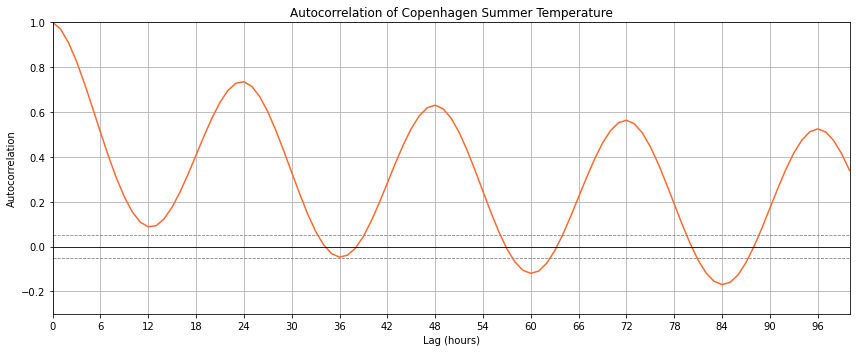

In [6]:
# Calculate autocorrelation manually
import pandas as pd
import matplotlib.pyplot as plt

acf_values = [hourly["temp_c"].autocorr(lag=i) for i in range(101)]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(range(101), acf_values, color="#ff692e", lw=1.5)
ax.axhline(0, color="black", lw=0.8)
ax.axhline(0.05, color="gray", lw=0.8, linestyle="--")
ax.axhline(-0.05, color="gray", lw=0.8, linestyle="--")

ax.xaxis.set_major_locator(plt.MultipleLocator(6))
ax.set_xlim(0, 100)
ax.set_ylim(-0.3, 1.0)

ax.set_title("Autocorrelation of Copenhagen Summer Temperature")
ax.set_xlabel("Lag (hours)")
ax.set_ylabel("Autocorrelation")
ax.grid(True)

plt.tight_layout()
plt.show()

*How to read the plot*

The dashed lines are the significance threshold — anything outside them is statistically significant correlation, not just noise.

- **Lag 0** — correlation = 1.0. The temperature is perfectly correlated with itself.

- **Lag 1–6** — correlation drops fast. The further back you go, the less similar the temperature becomes.

- **Lag ~6** — The correlation flattens out before bouncing back up.

- **Lag ~12** — first zero crossing. The temperature is now uncorrelated with itself. Theoretically this would be the best candidate for τ in phase space. 

- **Lag 24** — first local maximum. The temperature is strongly correlated with the temperature exactly 24 hours ago — the daily cycle showing up mathematically.

After every 24 hours the wave pattern slowly decays. The atmosphere gradually "forgets" — weather from five days ago is less predictable than yesterday's.

## Choosing the Embedding Lag τ

Before reconstructing the phase space, we need to choose the right time delay τ. The autocorrelation analysis suggested two candidates:

- **τ = 6h** — first local minimum
- **τ = 12h** — first zero crossing (visually)

We also include **τ = 24h** as a reference case — since 24 hours is exactly the daily cycle, the two axes should be strongly correlated, which would produce a poorly unfolded attractor.

The three reconstructions are shown below for comparison.

## Phase space reconstruction plot:


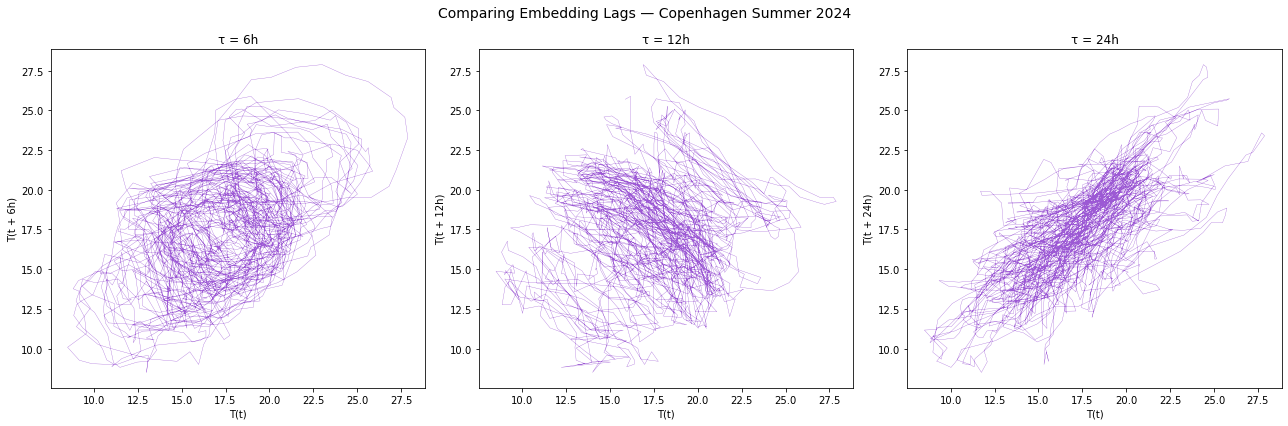

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

T = hourly["temp_c"].values

for ax, tau, label in zip(axes, [6, 12, 24], ["6h", "12h", "24h"]):
    T1 = T[:-2*tau]
    T2 = T[tau:-tau]
    ax.plot(T1, T2, lw=0.3, color="#9c59d4")
    ax.set_title("τ = " + label)
    ax.set_xlabel("T(t)")
    ax.set_ylabel("T(t + " + label + ")")

plt.suptitle("Comparing Embedding Lags — Copenhagen Summer 2024", fontsize=14)
plt.tight_layout()
plt.show()

**Comments**

- **τ = 6h** produces the most structured and compact attractor. The trajectory winds around a clear centre with visible organisation.

- **τ = 12h** is more spread out. The axes carry less redundant information but the structure is harder to read than τ = 6.

- **τ = 24h** collapses into a diagonal shape (as expected, T(t) and T(t + 24h) are correlated due to the daily cycle). This means the two axes are not independent enough to unfold the attractor properly.

Based on this comparison, **τ = 6h** is chosen as the most suitable lag for the full phase space reconstruction.

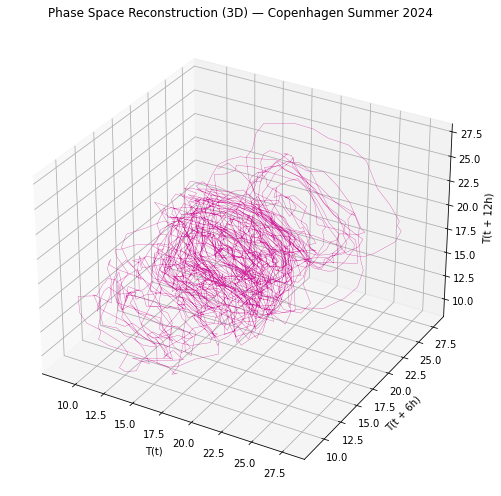

In [11]:
# Recompute with tau = 6
tau = 6
T = hourly["temp_c"].values
T1 = T[:-2*tau]
T2 = T[tau:-tau]
T3 = T[2*tau:]

# now 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot(T1, T2, T3, lw=0.3, color="#d12c9f")

ax.set_title("Phase Space Reconstruction (3D) — Copenhagen Summer 2024")
ax.set_xlabel("T(t)")
ax.set_ylabel("T(t + 6h)")
ax.set_zlabel("T(t + 12h)")

plt.tight_layout()
plt.show()

Comments:

The 3D reconstruction shows a structured, bounded attractor. The trajectory are moving continuously through the same region of phase space, visiting similar states repeatedly but never settling into a fixed pattern. This is the same property we saw in the Lorenz attractor.

Unlike the Lorenz butterfly with its two distinct wings, this attractor is a single tangled cloud. This is consistent with the atmosphere being a much higher-dimensional system than the three-equation Lorenz model — the temperature signal we observe is just one projection of an enormously complex system.
The trajectory stays concentrated in a structured region. This is a direct evidence of deterministic dynamics in the data.

---

## Conclusion

Starting from a single temperature time series — one number recorded every hour at a weather station in Copenhagen — we have reconstructed the geometric signature of atmospheric chaos.

The result is consistent with what the Lorenz system predicted in the previous notebook: the atmosphere is a deterministic system, but one that is very sensitive to initial conditions. The reconstructed attractor has clear structure, but the trajectory never repeats. Prediction is possible in the short term, but the system will always eventually surprise you.That is not a flaw in our models but a property of the atmosphere itself.